In [1]:
print("Notebook is working")

Notebook is working


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ============================================================
# GLOBAL STYLE SETTINGS
# Clean, professional look for LinkedIn and dashboard
# ============================================================
plt.rcParams.update({
    "figure.facecolor":  "#0f1117",
    "axes.facecolor":    "#0f1117",
    "axes.edgecolor":    "#444444",
    "axes.labelcolor":   "#ffffff",
    "axes.titlecolor":   "#ffffff",
    "xtick.color":       "#aaaaaa",
    "ytick.color":       "#aaaaaa",
    "text.color":        "#ffffff",
    "grid.color":        "#2a2a2a",
    "grid.linestyle":    "--",
    "grid.linewidth":    0.6,
    "font.family":       "sans-serif",
    "font.size":         11,
})

# Paths
BASE_DIR     = Path().resolve().parent
DATA_PATH    = BASE_DIR / "data" / "processed" / "imdb_final.csv"
VISUALS_DIR  = BASE_DIR / "visuals"
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

# Load data
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} movies")
print(f"Columns: {list(df.columns)}")

Loaded 250 movies
Columns: ['rank', 'title', 'year', 'rating', 'votes', 'genre', 'runtime_minutes', 'imdb_id', 'imdb_url', 'weighted_score', 'plot', 'awards', 'metascore', 'imdb_rating', 'box_office', 'director', 'language', 'country', 'sentiment_compound', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'sentiment_intensity', 'sentiment_label', 'age_years', 'votes_per_year', 'longevity_score', 'quadrant', 'primary_genre']


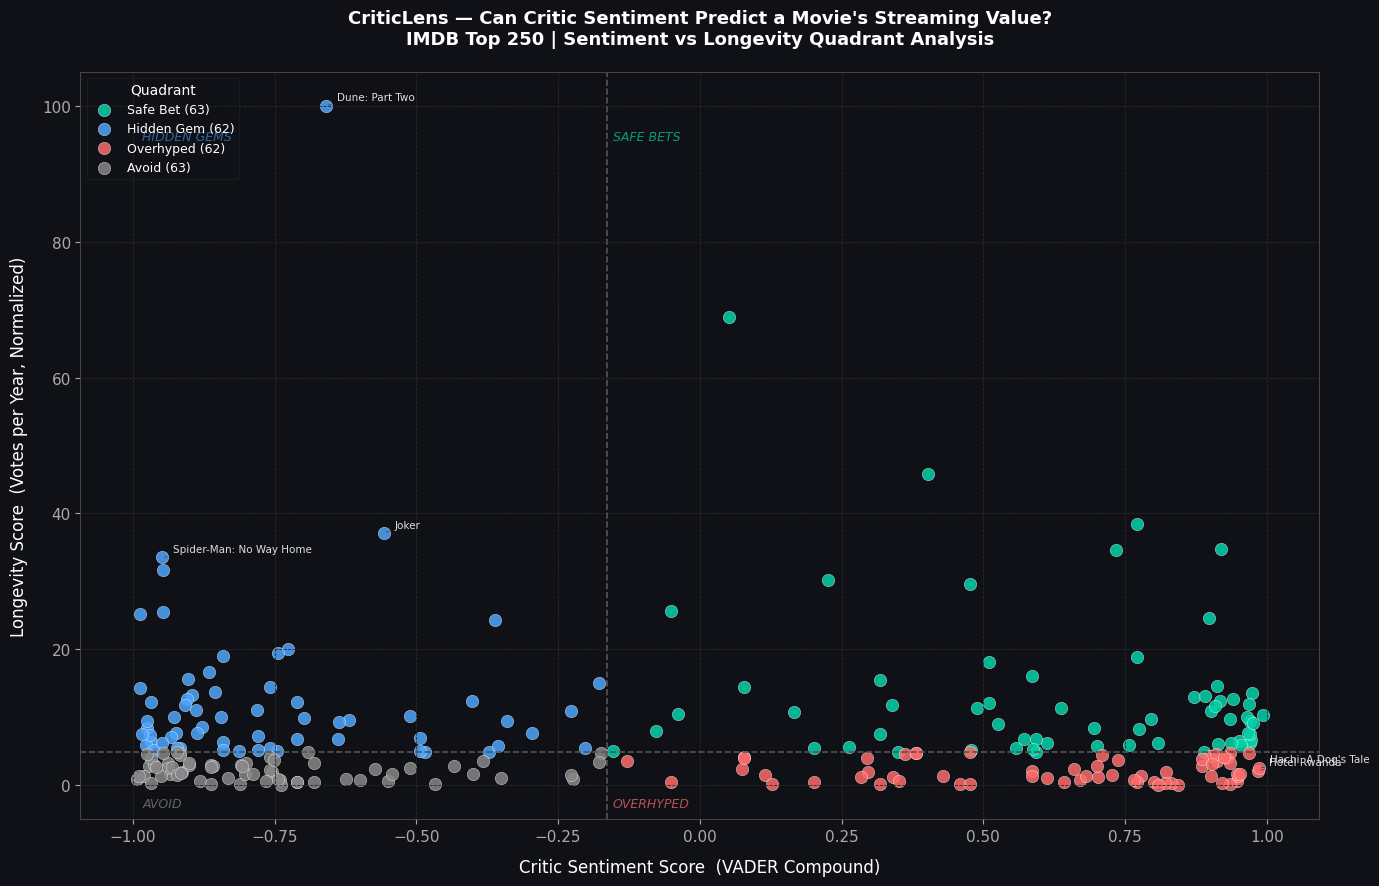

Saved: C:\Users\pranav sandanamyna\OneDrive\Desktop\criticlens\visuals\01_quadrant_scatter.png


In [3]:
# ============================================================
# VISUAL 1 — QUADRANT SCATTER PLOT
# Hero visual. X = sentiment, Y = longevity, color = quadrant
# This is the money shot for LinkedIn
# ============================================================

QUADRANT_COLORS = {
    "Safe Bet":   "#00d4aa",
    "Hidden Gem": "#4da6ff",
    "Overhyped":  "#ff6b6b",
    "Avoid":      "#888888",
}

fig, ax = plt.subplots(figsize=(14, 9))

for quadrant, color in QUADRANT_COLORS.items():
    subset = df[df["quadrant"] == quadrant]
    ax.scatter(
        subset["sentiment_compound"],
        subset["longevity_score"],
        c=color,
        label=f"{quadrant} ({len(subset)})",
        alpha=0.85,
        s=80,
        edgecolors="white",
        linewidths=0.3,
    )

# Median lines
sentiment_median = df["sentiment_compound"].median()
longevity_median = df["longevity_score"].median()

ax.axvline(x=sentiment_median, color="#555555", linestyle="--", linewidth=1.2)
ax.axhline(y=longevity_median, color="#555555", linestyle="--", linewidth=1.2)

# Label quadrant zones
ax.text(df["sentiment_compound"].min() + 0.01, df["longevity_score"].max() - 5,
        "HIDDEN GEMS", color="#4da6ff", fontsize=9, alpha=0.7, style="italic")
ax.text(sentiment_median + 0.01, df["longevity_score"].max() - 5,
        "SAFE BETS", color="#00d4aa", fontsize=9, alpha=0.7, style="italic")
ax.text(df["sentiment_compound"].min() + 0.01, longevity_median - 8,
        "AVOID", color="#888888", fontsize=9, alpha=0.7, style="italic")
ax.text(sentiment_median + 0.01, longevity_median - 8,
        "OVERHYPED", color="#ff6b6b", fontsize=9, alpha=0.7, style="italic")

# Annotate top 5 most interesting outliers
top_outliers = pd.concat([
    df[df["quadrant"] == "Hidden Gem"].nlargest(3, "longevity_score"),
    df[df["quadrant"] == "Overhyped"].nlargest(2, "sentiment_compound"),
])

for _, row in top_outliers.iterrows():
    ax.annotate(
        row["title"],
        xy=(row["sentiment_compound"], row["longevity_score"]),
        xytext=(8, 4),
        textcoords="offset points",
        fontsize=7.5,
        color="#dddddd",
        arrowprops=dict(arrowstyle="-", color="#555555", lw=0.8),
    )

ax.set_xlabel("Critic Sentiment Score  (VADER Compound)", fontsize=12, labelpad=10)
ax.set_ylabel("Longevity Score  (Votes per Year, Normalized)", fontsize=12, labelpad=10)
ax.set_title(
    "CriticLens — Can Critic Sentiment Predict a Movie's Streaming Value?\n"
    "IMDB Top 250 | Sentiment vs Longevity Quadrant Analysis",
    fontsize=13, pad=20, fontweight="bold"
)

ax.legend(
    title="Quadrant",
    title_fontsize=10,
    fontsize=9,
    loc="upper left",
    framealpha=0.2,
    edgecolor="#444444",
)

ax.grid(True)
plt.tight_layout()

output = VISUALS_DIR / "01_quadrant_scatter.png"
plt.savefig(output, dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"Saved: {output}")

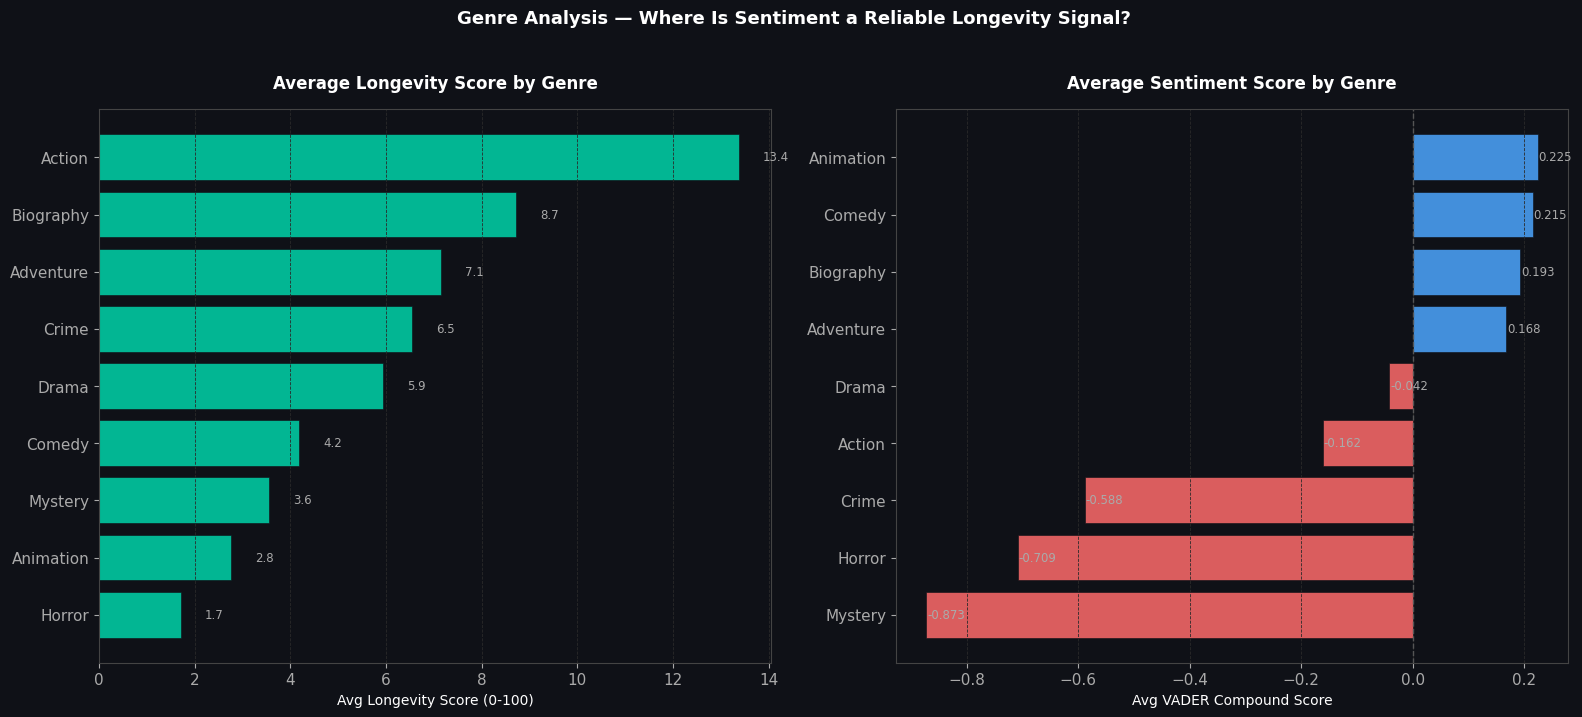

Saved: C:\Users\pranav sandanamyna\OneDrive\Desktop\criticlens\visuals\02_genre_breakdown.png


In [4]:
# ============================================================
# VISUAL 2 — GENRE BREAKDOWN BAR CHART
# Average sentiment vs average longevity per genre
# Shows which genres are reliable signals for licensing
# ============================================================

df["primary_genre"] = df["genre"].str.split(",").str[0].str.strip()

genre_df = df.groupby("primary_genre").agg(
    avg_sentiment = ("sentiment_compound", "mean"),
    avg_longevity = ("longevity_score", "mean"),
    count         = ("title", "count"),
).reset_index()

genre_df = genre_df[genre_df["count"] >= 3].sort_values("avg_longevity", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — Longevity by genre
bars1 = axes[0].barh(
    genre_df["primary_genre"],
    genre_df["avg_longevity"],
    color="#00d4aa",
    alpha=0.85,
    edgecolor="#0f1117",
    linewidth=0.5,
)
axes[0].set_title("Average Longevity Score by Genre", fontsize=12, fontweight="bold", pad=15)
axes[0].set_xlabel("Avg Longevity Score (0-100)", fontsize=10)
axes[0].grid(True, axis="x")

for bar, val in zip(bars1, genre_df["avg_longevity"]):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}", va="center", fontsize=8.5, color="#aaaaaa")

# Right — Sentiment by genre
genre_df_sent = genre_df.sort_values("avg_sentiment", ascending=True)
colors_sent = ["#ff6b6b" if v < 0 else "#4da6ff" for v in genre_df_sent["avg_sentiment"]]

bars2 = axes[1].barh(
    genre_df_sent["primary_genre"],
    genre_df_sent["avg_sentiment"],
    color=colors_sent,
    alpha=0.85,
    edgecolor="#0f1117",
    linewidth=0.5,
)
axes[1].set_title("Average Sentiment Score by Genre", fontsize=12, fontweight="bold", pad=15)
axes[1].set_xlabel("Avg VADER Compound Score", fontsize=10)
axes[1].axvline(x=0, color="#555555", linestyle="--", linewidth=1)
axes[1].grid(True, axis="x")

for bar, val in zip(bars2, genre_df_sent["avg_sentiment"]):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=8.5, color="#aaaaaa")

fig.suptitle(
    "Genre Analysis — Where Is Sentiment a Reliable Longevity Signal?",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()

output = VISUALS_DIR / "02_genre_breakdown.png"
plt.savefig(output, dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"Saved: {output}")

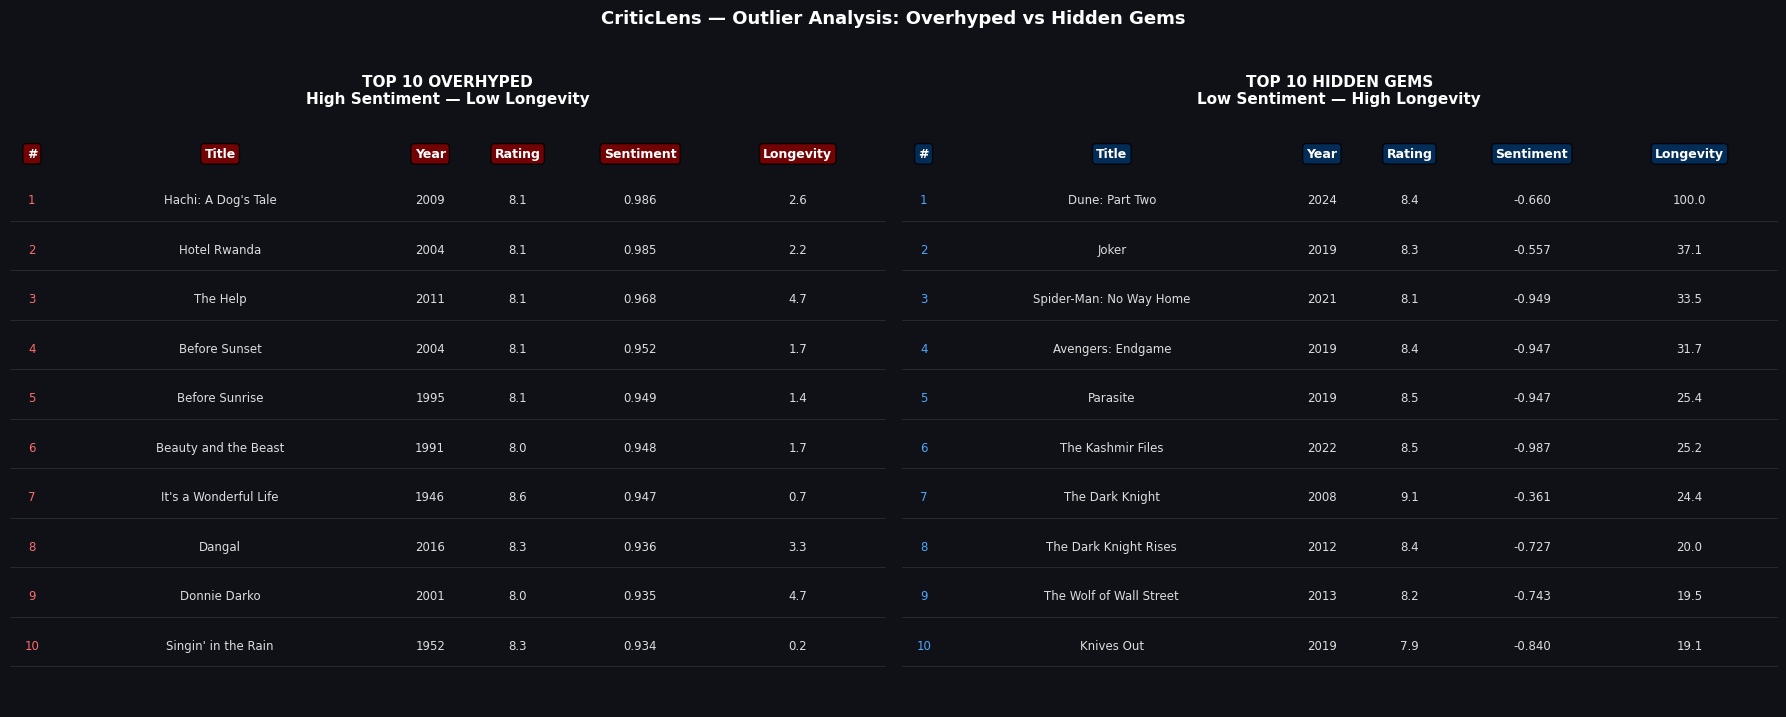

Saved: C:\Users\pranav sandanamyna\OneDrive\Desktop\criticlens\visuals\03_outlier_tables.png


In [7]:
overhyped = df[df["quadrant"] == "Overhyped"].nlargest(10, "sentiment_compound")[
    ["title", "year", "rating", "sentiment_compound", "longevity_score"]
].reset_index(drop=True)

hidden_gems = df[df["quadrant"] == "Hidden Gem"].nlargest(10, "longevity_score")[
    ["title", "year", "rating", "sentiment_compound", "longevity_score"]
].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

def render_table(ax, data, title, header_color, rank_color):
    ax.axis("off")

    col_labels = ["#", "Title", "Year", "Rating", "Sentiment", "Longevity"]
    col_widths  = [0.05, 0.38, 0.10, 0.10, 0.18, 0.18]

    # Header
    x = 0
    for label, width in zip(col_labels, col_widths):
        ax.text(x + width/2, 0.95, label,
                ha="center", va="center",
                fontsize=9, fontweight="bold",
                color="white",
                transform=ax.transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor=header_color, alpha=0.8))
        x += width

    # Rows
    for i, row in data.iterrows():
        y = 0.87 - i * 0.085

        values = [
            str(i + 1),
            row["title"][:28] + "…" if len(str(row["title"])) > 28 else row["title"],
            str(int(row["year"])),
            str(row["rating"]),
            f"{row['sentiment_compound']:.3f}",
            f"{row['longevity_score']:.1f}",
        ]

        x = 0
        for val, width in zip(values, col_widths):
            color = rank_color if val == str(i + 1) else "#dddddd"
            ax.text(x + width/2, y, val,
                    ha="center", va="center",
                    fontsize=8.5, color=color,
                    transform=ax.transAxes)
            x += width

        # Fixed — removed transform argument from axhline
        ax.plot([0, 1], [y - 0.035, y - 0.035],
                color="#333333", linewidth=0.5,
                transform=ax.transAxes, clip_on=False)

    ax.set_title(title, fontsize=11, fontweight="bold", pad=15, color="white")

render_table(axes[0], overhyped,
             "TOP 10 OVERHYPED\nHigh Sentiment — Low Longevity",
             "#8b0000", "#ff6b6b")

render_table(axes[1], hidden_gems,
             "TOP 10 HIDDEN GEMS\nLow Sentiment — High Longevity",
             "#003366", "#4da6ff")

fig.suptitle(
    "CriticLens — Outlier Analysis: Overhyped vs Hidden Gems",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()

output = VISUALS_DIR / "03_outlier_tables.png"
plt.savefig(output, dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"Saved: {output}")

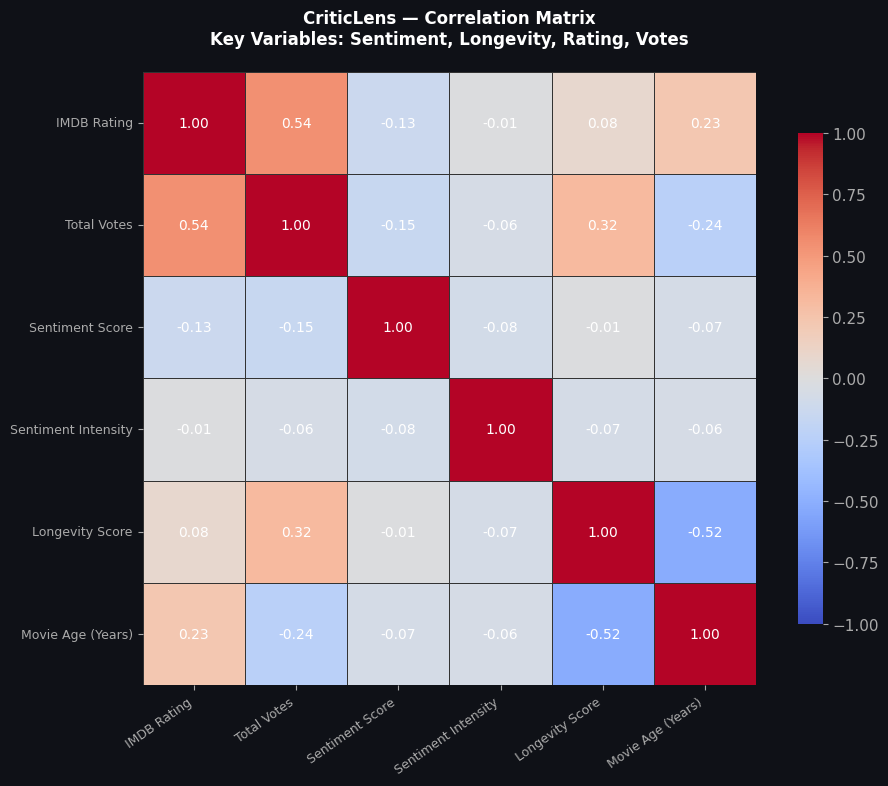

Saved: C:\Users\pranav sandanamyna\OneDrive\Desktop\criticlens\visuals\04_correlation_heatmap.png


In [8]:
# ============================================================
# VISUAL 4 — CORRELATION HEATMAP
# Shows relationships between all key numeric variables
# Demonstrates you understand variable relationships
# ============================================================

corr_cols = [
    "rating",
    "votes",
    "sentiment_compound",
    "sentiment_intensity",
    "longevity_score",
    "age_years",
]

# Only keep columns that exist in dataframe
corr_cols = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].corr().round(2)

# Clean labels for display
label_map = {
    "rating":               "IMDB Rating",
    "votes":                "Total Votes",
    "sentiment_compound":   "Sentiment Score",
    "sentiment_intensity":  "Sentiment Intensity",
    "longevity_score":      "Longevity Score",
    "age_years":            "Movie Age (Years)",
}
corr_matrix.index   = [label_map.get(c, c) for c in corr_matrix.index]
corr_matrix.columns = [label_map.get(c, c) for c in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="#333333",
    annot_kws={"size": 10, "color": "white"},
    ax=ax,
    cbar_kws={"shrink": 0.8},
)

ax.set_title(
    "CriticLens — Correlation Matrix\nKey Variables: Sentiment, Longevity, Rating, Votes",
    fontsize=12, fontweight="bold", pad=20
)

plt.xticks(rotation=35, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

output = VISUALS_DIR / "04_correlation_heatmap.png"
plt.savefig(output, dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"Saved: {output}")

In [9]:
print("Checking all visuals saved correctly:\n")

visuals = [
    "01_quadrant_scatter.png",
    "02_genre_breakdown.png",
    "03_outlier_tables.png",
    "04_correlation_heatmap.png",
]

all_good = True
for v in visuals:
    path = VISUALS_DIR / v
    exists = path.exists()
    size   = path.stat().st_size if exists else 0
    status = "✓" if exists and size > 10000 else "✗ PROBLEM"
    print(f"  {status}  {v}  ({size:,} bytes)")
    if not exists or size < 10000:
        all_good = False

print(f"\n{'All visuals saved successfully.' if all_good else 'Some visuals missing — rerun those cells.'}")

Checking all visuals saved correctly:

  ✓  01_quadrant_scatter.png  (217,242 bytes)
  ✓  02_genre_breakdown.png  (139,913 bytes)
  ✓  03_outlier_tables.png  (166,799 bytes)
  ✓  04_correlation_heatmap.png  (120,572 bytes)

All visuals saved successfully.
